### Banking Transaction Analysis

In [23]:
from PIL import Image

# Open the image file
img = Image.open("images\istockphoto-1198048600-1024x1024.jpg")
img.show()

### Banking Transaction Analysis

# 1. Project Overview

For this project, we will use data cleaning, imputation, analisis, and visualization to generate insights for a business stakeholder. 

The objective is to analyze banking transactions to identify fraud patterns, transaction success rates, and other key financial insights.

Key objectives:

* Understand transaction trends and types.

* Identify fraudalent transactions and common fraud characteristis.

* Determine factors contributing to failed transactions.

* Analyze the impact of device type and network conditions on fraud and failures.

* Examine the geographical distribution of fraudulent transactions.

* provide data-driven recommendations for improving banking security and efficiency.
 
 


# 2. Data Understanding

 Before conducting any analysis, it is crucial to understand the structure and contents of the dataset. This includes examining the data types, identifying missing values, and understanding key features.
 
 This section focuses on gaining an in-depth understanding of the banking transaction dataset. By exploring the data structure, transaction patterns, fraud occurrences, and failure reasons, we can extract key insights that will help improve banking security and transaction efficiency.

* **Transaction Details:** Includes Transaction ID, Sender $ Receiver Account IDs, Amount, Type, Timestamp, and Status.

* **Fraud Indicators:** The Fraud Flag column highlights whether a transaction is fraudulent.

* **Geolocation & Device Information:** Latitude/Longitude coordinates and Device Used help in assessing fraud patterns.

* **Network Characteristics:** Network Slice ID, Latency (ms), and Slice Bandwidth (Mbps) influence transaction success rates.

* **Security Data:** The presence of PIN Code indicates security measures used in transactions.




### **Importing Essential Libraries for Data Analysis and Visualization**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates


### **Load dataset**

In [3]:
df = pd.read_csv("transaction_data.csv")

### **Display basic information**

In [4]:
# Display information
df.info
#Display first five
df.head

<bound method NDFrame.head of     Transaction ID Sender Account ID Receiver Account ID  Transaction Amount  \
0    TXN9520068950          ACC14994            ACC16656              495.90   
1    TXN9412011085          ACC58958            ACC32826              529.62   
2    TXN4407425052          ACC56321            ACC92481              862.47   
3    TXN2214150284          ACC48650            ACC76457             1129.88   
4    TXN4247571145          ACC60921            ACC11419              933.24   
..             ...               ...                 ...                 ...   
995  TXN7395336359          ACC79886            ACC14903             1340.76   
996  TXN2215717837          ACC95972            ACC50750              483.36   
997  TXN1676848215          ACC95938            ACC18507              199.81   
998  TXN2479413280          ACC76523            ACC95234             1341.86   
999  TXN3992032184          ACC16789            ACC21980              495.36   

    Trans

### **Data Exploration** 

Exploring the data allows us to identify missing values, analyze transaction distributions, and detect patterns.

### **Missing Values**

Checking for missing values ensures data completeness and helps in deciding how to handle them.

In [5]:
# check for sum of missing values
print(df.isnull().sum())

Transaction ID                      0
Sender Account ID                   0
Receiver Account ID                 0
Transaction Amount                  0
Transaction Type                    0
Timestamp                           0
Transaction Status                  0
Fraud Flag                          0
Geolocation (Latitude/Longitude)    0
Device Used                         0
Network Slice ID                    0
Latency (ms)                        0
Slice Bandwidth (Mbps)              0
PIN Code                            0
dtype: int64


### **Summarize key numerical features**
Summarizing numerical features provides insights into transaction amounts, latencies, and other key metrics.


In [6]:
print(df.describe())

       Transaction Amount  Latency (ms)  Slice Bandwidth (Mbps)    PIN Code
count          1000.00000   1000.000000              1000.00000  1000.00000
mean            771.16529     11.688000               148.51100  5458.66600
std             411.01925      5.131958                57.78634  2603.03646
min              51.89000      3.000000                50.00000  1000.00000
25%             423.34750      7.000000                98.00000  3281.75000
50%             761.65500     12.000000               148.00000  5385.50000
75%            1122.67250     16.000000               198.25000  7535.00000
max            1497.76000     20.000000               250.00000  9999.00000


### **Distribution of Transactions Across Different Types**
Understanding the distribution of transaction types allows us to assess which transactions are most common.

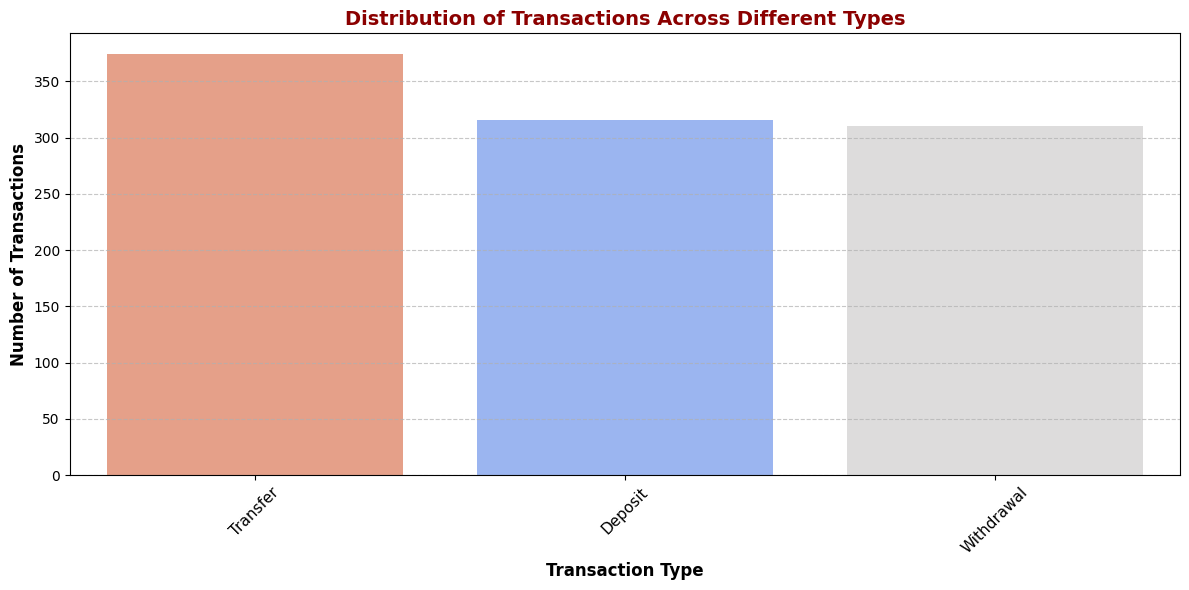

In [7]:
# Create figure with better aspect ratio
plt.figure(figsize=(12, 6))  

# Create count plot with clear color contrast
sns.countplot(data=df, x='Transaction Type',hue='Transaction Type', palette='coolwarm', order=df['Transaction Type'].value_counts().index)

# Enhancing Labels & Title for Better Interpretation
plt.title("Distribution of Transactions Across Different Types", fontsize=14, fontweight='bold', color='darkred')
plt.xlabel("Transaction Type", fontsize=12, fontweight='bold', color='black')
plt.ylabel("Number of Transactions", fontsize=12, fontweight='bold', color='black')

# Rotating x-axis labels for better visibility
plt.xticks(rotation=45, fontsize=11, color='black')  

# Adding a grid for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display plot with adjusted layout
plt.tight_layout()
plt.show()

# **3. Data Preparation**


### **Data Cleaning**

Before analysis, we must clean the data by handling missing values, formatting date columns, and creating additional features for insights.

* Remove missing values from critical columns (Transaction Amount, Transaction Type, Transaction Status, Fraud Flag).

* Filter relevant columns

* Convert Timestamp column to datetime format for better time-based analysis.

* Extract additional features: Transaction Day and Transaction Hour to analyze transaction trends over time.

### Handling missing values

In [8]:
#Drop missing values
# Handling missing values
df = df.dropna(subset=['Transaction Amount', 'Transaction Type', 'Transaction Status', 'Fraud Flag'])
df.head()

,Transaction ID,Sender Account ID,Receiver Account ID,Transaction Amount,Transaction Type,Timestamp,Transaction Status,Fraud Flag,Geolocation (Latitude/Longitude),Device Used,Network Slice ID,Latency (ms),Slice Bandwidth (Mbps),PIN Code
0,TXN9520068950,ACC14994,ACC16656,495.90,Deposit,2025-01-17 10:14:00,Failed,True,"34.0522 N, -74.006 W",Desktop,Slice3,10,179,3075
1,TXN9412011085,ACC58958,ACC32826,529.62,Withdrawal,2025-01-17 10:51:00,Success,False,"35.6895 N, -118.2437 W",Mobile,Slice2,11,89,2369
2,TXN4407425052,ACC56321,ACC92481,862.47,Withdrawal,2025-01-17 10:50:00,Failed,False,"48.8566 N, 2.3522 W",Mobile,Slice1,4,53,8039
3,TXN2214150284,ACC48650,ACC76457,1129.88,Transfer,2025-01-17 10:56:00,Success,True,"34.0522 N, -74.006 W",Mobile,Slice3,10,127,6374
4,TXN4247571145,ACC60921,ACC11419,933.24,Deposit,2025-01-17 10:25:00,Success,True,"55.7558 N, 37.6173 W",Mobile,Slice3,20,191,8375


### Convert Timestamp column

In [9]:
# Convert Timestamp column
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.head()

,Transaction ID,Sender Account ID,Receiver Account ID,Transaction Amount,Transaction Type,Timestamp,Transaction Status,Fraud Flag,Geolocation (Latitude/Longitude),Device Used,Network Slice ID,Latency (ms),Slice Bandwidth (Mbps),PIN Code
0,TXN9520068950,ACC14994,ACC16656,495.90,Deposit,2025-01-17 10:14:00,Failed,True,"34.0522 N, -74.006 W",Desktop,Slice3,10,179,3075
1,TXN9412011085,ACC58958,ACC32826,529.62,Withdrawal,2025-01-17 10:51:00,Success,False,"35.6895 N, -118.2437 W",Mobile,Slice2,11,89,2369
2,TXN4407425052,ACC56321,ACC92481,862.47,Withdrawal,2025-01-17 10:50:00,Failed,False,"48.8566 N, 2.3522 W",Mobile,Slice1,4,53,8039
3,TXN2214150284,ACC48650,ACC76457,1129.88,Transfer,2025-01-17 10:56:00,Success,True,"34.0522 N, -74.006 W",Mobile,Slice3,10,127,6374
4,TXN4247571145,ACC60921,ACC11419,933.24,Deposit,2025-01-17 10:25:00,Success,True,"55.7558 N, 37.6173 W",Mobile,Slice3,20,191,8375


### Extract Transaction day and hour

In [10]:
# Extract transaction day and hour
df['Transaction Day'] = df['Timestamp'].dt.date
df['Transaction Hour'] = df['Timestamp'].dt.hour
df.head()

,Transaction ID,Sender Account ID,Receiver Account ID,Transaction Amount,Transaction Type,Timestamp,Transaction Status,Fraud Flag,Geolocation (Latitude/Longitude),Device Used,Network Slice ID,Latency (ms),Slice Bandwidth (Mbps),PIN Code,Transaction Day,Transaction Hour
0,TXN9520068950,ACC14994,ACC16656,495.90,Deposit,2025-01-17 10:14:00,Failed,True,"34.0522 N, -74.006 W",Desktop,Slice3,10,179,3075,2025-01-17,10
1,TXN9412011085,ACC58958,ACC32826,529.62,Withdrawal,2025-01-17 10:51:00,Success,False,"35.6895 N, -118.2437 W",Mobile,Slice2,11,89,2369,2025-01-17,10
2,TXN4407425052,ACC56321,ACC92481,862.47,Withdrawal,2025-01-17 10:50:00,Failed,False,"48.8566 N, 2.3522 W",Mobile,Slice1,4,53,8039,2025-01-17,10
3,TXN2214150284,ACC48650,ACC76457,1129.88,Transfer,2025-01-17 10:56:00,Success,True,"34.0522 N, -74.006 W",Mobile,Slice3,10,127,6374,2025-01-17,10
4,TXN4247571145,ACC60921,ACC11419,933.24,Deposit,2025-01-17 10:25:00,Success,True,"55.7558 N, 37.6173 W",Mobile,Slice3,20,191,8375,2025-01-17,10


In [11]:
#Display information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Transaction ID                    1000 non-null   object        
 1   Sender Account ID                 1000 non-null   object        
 2   Receiver Account ID               1000 non-null   object        
 3   Transaction Amount                1000 non-null   float64       
 4   Transaction Type                  1000 non-null   object        
 5   Timestamp                         1000 non-null   datetime64[ns]
 6   Transaction Status                1000 non-null   object        
 7   Fraud Flag                        1000 non-null   bool          
 8   Geolocation (Latitude/Longitude)  1000 non-null   object        
 9   Device Used                       1000 non-null   object        
 10  Network Slice ID                  1000 non-null  

# 4. **Data Analysis**

### **Fraud Analysis**

Fraud analysis is essential for understanding fraudilent transaction patterns and implementing security measures. By examining fraud occurrences across different transaction types, time periods, and network conditions, we can identify high-risk factors.

### **Fraud Trends Across Transaction Types**

This visualization highlights which transaction types are most susceptible to fraud.



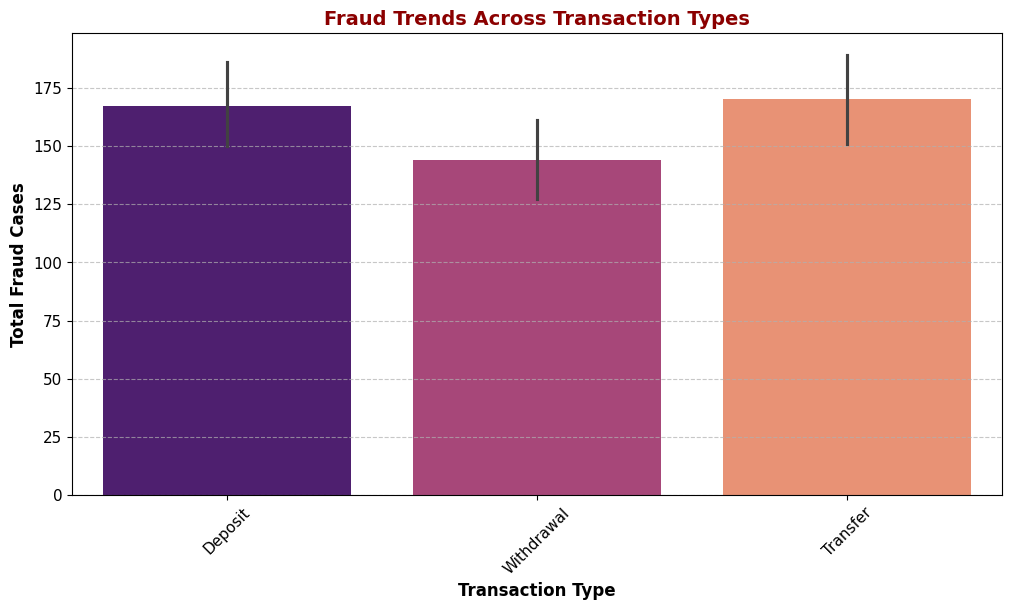

In [12]:
plt.figure(figsize=(12, 6))  # Adjust figure size for better visibility

# Convert 'Transaction Type' to categorical for proper ordering
df['Transaction Type'] = df['Transaction Type'].astype(str)

# Create the bar plot with summed fraud occurrences per transaction type
sns.barplot(x='Transaction Type', y='Fraud Flag', data=df, estimator=sum,hue='Transaction Type', palette='magma', legend=False)

# Enhancing Labels for Better Understanding
plt.title("Fraud Trends Across Transaction Types", fontsize=14, fontweight='bold', color='darkred')
plt.xlabel("Transaction Type", fontsize=12, fontweight='bold', color='black')
plt.ylabel("Total Fraud Cases", fontsize=12, fontweight='bold', color='black')

# Rotate X-Ticks for Better Readability
plt.xticks(rotation=45, fontsize=11, color='black')  # Adjust based on transaction type length
plt.yticks(fontsize=11, color='black')

# Adding Grid for Better Visibility
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

### **Fraud Transaction Trends Over Time**
Tracking fraud cases over time helps in identifying seasonal trends or spikes in fraudulent activity. This can assist in implementing targeted security measures during high-risk periods.

### Using an Histogram to represent Fraud Transaction Trends Over Time

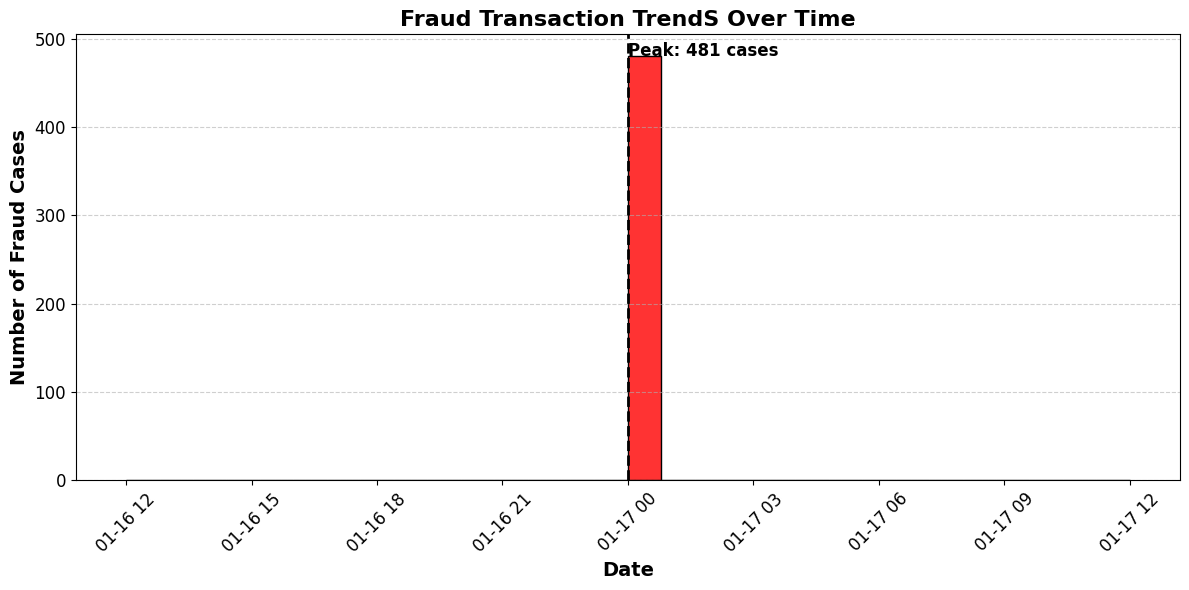

In [13]:
# Ensure 'Transaction Day' is in datetime format
df['Transaction Day'] = pd.to_datetime(df['Transaction Day'])

# Set figure size
plt.figure(figsize=(12, 6))

# Create histogram plot for fraud cases over time
ax = sns.histplot(df[df['Fraud Flag'] == True]['Transaction Day'], 
                  bins=30, kde=True, color='red', alpha=0.8)

# Title & labels
plt.title("Fraud Transaction TrendS Over Time", fontsize=16, fontweight='bold', color='black')
plt.xlabel("Date", fontsize=14, fontweight='bold', color='black')
plt.ylabel("Number of Fraud Cases", fontsize=14, fontweight='bold', color='black')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')

# Add grid for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate the highest fraud peak
max_fraud = df[df['Fraud Flag'] == True]['Transaction Day'].value_counts().max()
peak_day = df[df['Fraud Flag'] == True]['Transaction Day'].value_counts().idxmax()
plt.axvline(x=peak_day, color='black', linestyle='dashed', linewidth=2)
plt.text(peak_day, max_fraud, f'Peak: {max_fraud} cases', color='black', fontsize=12, fontweight='bold')

# Improve layout
plt.tight_layout()

# Show plot
plt.show()

### Using a Line Plot to represent  Fraud Transaction Trends Over Time

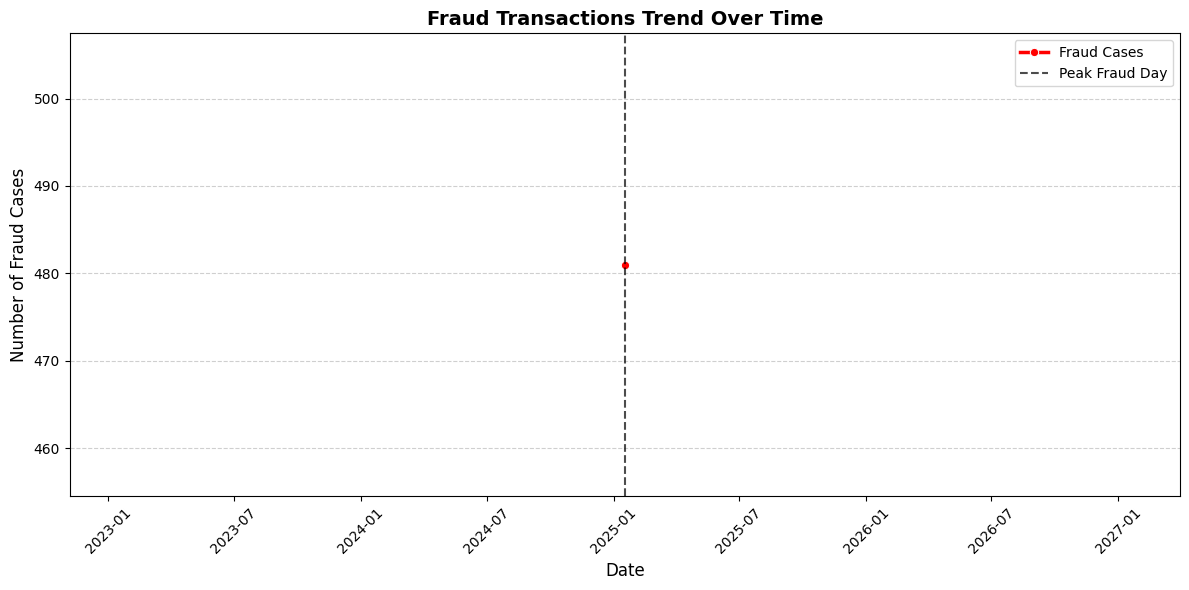

In [14]:
# Ensure 'Transaction Day' is in datetime format
df['Transaction Day'] = pd.to_datetime(df['Transaction Day'])

# Aggregate fraud cases by date
fraud_trend = df[df['Fraud Flag'] == True].groupby('Transaction Day').size()

# Set figure size
plt.figure(figsize=(12, 6))

# Create line plot
sns.lineplot(x=fraud_trend.index, y=fraud_trend.values, marker='o', color='red', linewidth=2.5, linestyle='-', label="Fraud Cases")

# Highlight peak fraud cases with a vertical line
plt.axvline(fraud_trend.idxmax(), color='black', linestyle='--', alpha=0.7, label="Peak Fraud Day")

# Title & labels
plt.title("Fraud Transactions Trend Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Fraud Cases", fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Add grid for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add legend
plt.legend()

# Improve layout
plt.tight_layout()

# Show plot
plt.show()

In [15]:
# Count the number of fraudulent transactions per day
fraud_per_day = df[df['Fraud Flag'] == 1]['Transaction Day'].value_counts()
fraud_per_day 

Transaction Day
2025-01-17    481
Name: count, dtype: int64

### **Fraud Cases by Device Type**

Understanding which devices are commonly used for fraud can help banks implement better security measures, such as multi-factor authentication on high-risk devices.

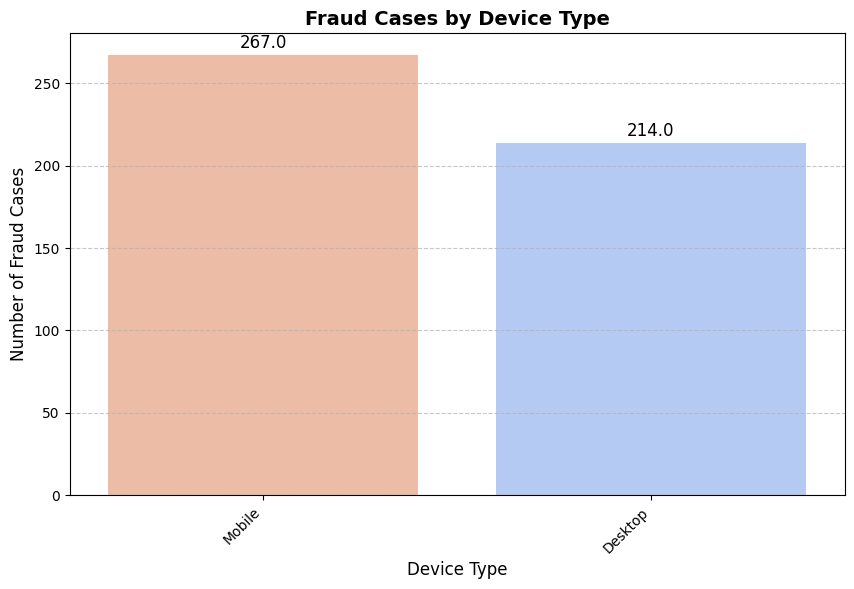

In [16]:
# Set figure size
plt.figure(figsize=(10, 6))

# Create an enhanced count plot with better labeling and aesthetics
ax = sns.countplot(
    data=df[df['Fraud Flag'] == True], 
    x='Device Used', 
    hue='Device Used',
    palette='coolwarm',
    legend=False,
    order=df[df['Fraud Flag'] == True]['Device Used'].value_counts().index  # Sorting devices by fraud count
)

# Add labels on bars to show exact count values
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

# Title and axis labels with improved font size
plt.title("Fraud Cases by Device Type", fontsize=14, fontweight='bold')
plt.xlabel("Device Type", fontsize=12)
plt.ylabel("Number of Fraud Cases", fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add grid lines for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

### **Geographical Distribution of Fraudulent Transactions**
Mapping fraudulent transactions helps in identifying high-risk locations where fraud is more prevalent.


In [17]:
# Check for missing or incorrectly formatted geolocation data
print(df['Geolocation (Latitude/Longitude)'].isnull().sum())  # Count NaN values
print(df['Geolocation (Latitude/Longitude)'].head(10))  # Sample data to inspect format

0
0      34.0522 N, -74.006 W
1    35.6895 N, -118.2437 W
2       48.8566 N, 2.3522 W
3      34.0522 N, -74.006 W
4      55.7558 N, 37.6173 W
5     35.6895 N, 139.6917 W
6       55.7558 N, 2.3522 W
7    48.8566 N, -118.2437 W
8    40.7128 N, -118.2437 W
9       34.0522 N, 2.3522 W
Name: Geolocation (Latitude/Longitude), dtype: object


In [18]:
 #Function to extract numeric latitude and longitude
def convert_geolocation(geo_str):
    parts = geo_str.split(", ")  # Split at the comma
    lat = float(parts[0].split(" ")[0])  # Extract latitude number
    lon = float(parts[1].split(" ")[0])  # Extract longitude number

    # Adjust for South and West values (making them negative)
    if "S" in parts[0]:
        lat *= -1
    if "W" in parts[1]:
        lon *= -1

    return pd.Series([lat, lon])

# Apply function to DataFrame
df[['Latitude', 'Longitude']] = df['Geolocation (Latitude/Longitude)'].apply(convert_geolocation)

# Display results
print(df[['Latitude', 'Longitude']].head())

   Latitude  Longitude
0   34.0522    74.0060
1   35.6895   118.2437
2   48.8566    -2.3522
3   34.0522    74.0060
4   55.7558   -37.6173


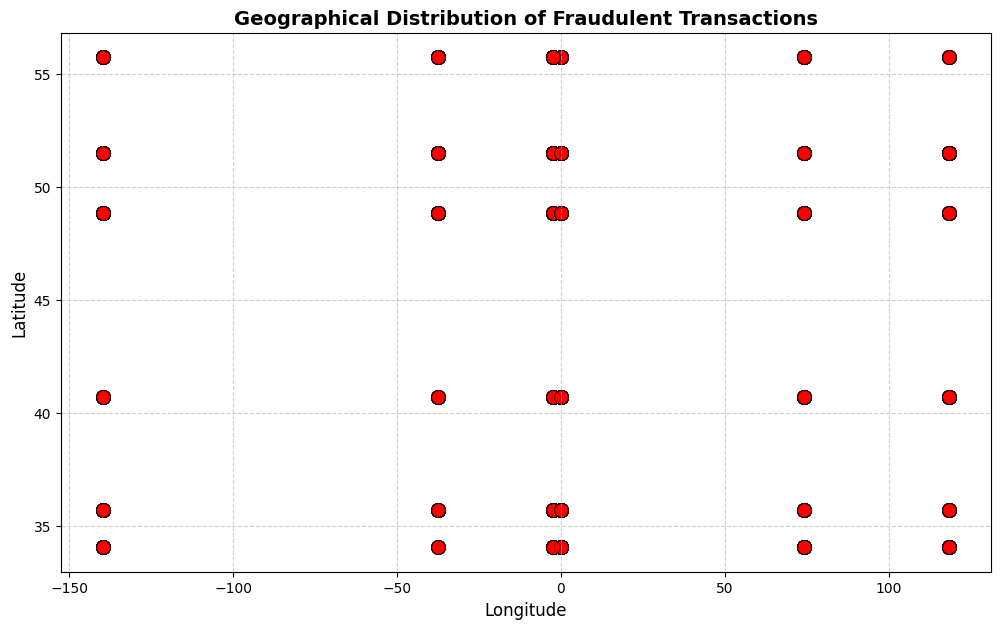

In [19]:

# Set figure size for better visibility
plt.figure(figsize=(12, 7))

# Create a scatter plot 
ax = sns.scatterplot(
    x=df[df['Fraud Flag'] == True]['Longitude'], 
    y=df[df['Fraud Flag'] == True]['Latitude'], 
    alpha=0.7,  # Adjust transparency to handle overlapping points
    edgecolor='black',  # Black edges for better distinction
    color='red', 
    s=100  # Increase marker size for visibility
)

# Add title and axis labels with clear font sizes
plt.title("Geographical Distribution of Fraudulent Transactions", fontsize=14, fontweight='bold')
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

# Add a grid to improve readability
plt.grid(linestyle='--', alpha=0.6)

# Show the plot
plt.show()

### **Transaction Success vs Failure Analysis**
Understanding transaction failures is key to improving banking operations. Analyzing success vs failure rates and identifying reasons behind failed transactions can help reduce errors and enhance user experience.
#### Transaction Status Distribution

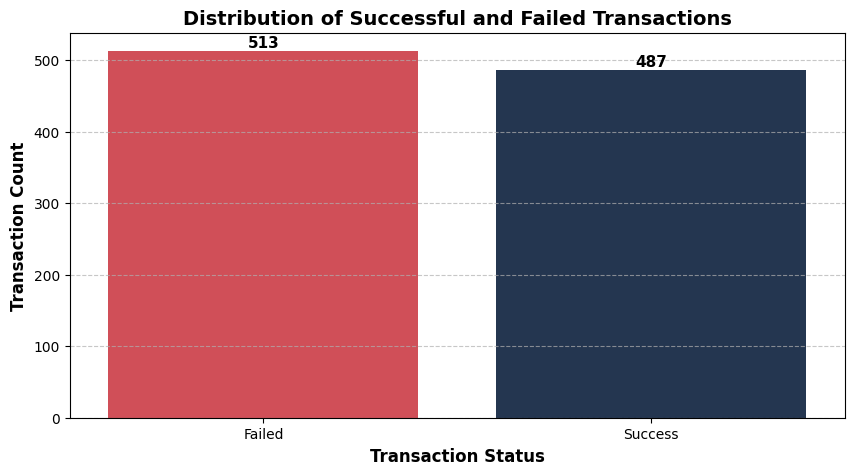

In [20]:
# Set figure size for better visualization
plt.figure(figsize=(10, 5))

# Create a count plot with a high-contrast palette
sns.countplot(data=df, x='Transaction Status',hue='Transaction Status', palette=['#E63946', '#1D3557'],legend = False)  # Red & Dark Blue

# Improve title clarity
plt.title("Distribution of Successful and Failed Transactions", fontsize=14, fontweight='bold')

# Label the axes properly
plt.xlabel("Transaction Status", fontsize=12, fontweight='bold')
plt.ylabel("Transaction Count", fontsize=12, fontweight='bold')

# Improve visibility of y-axis grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show precise values on top of bars
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width()/2, p.get_height() + 5,
             f'{int(p.get_height())}', ha='center', fontsize=11, fontweight='bold')

# Show the plot
plt.show()

##### Relationship between Latency and Transaction Success

Higher latency can lead to transaction failures. This analysis explores the impact of network delays on transaction status.

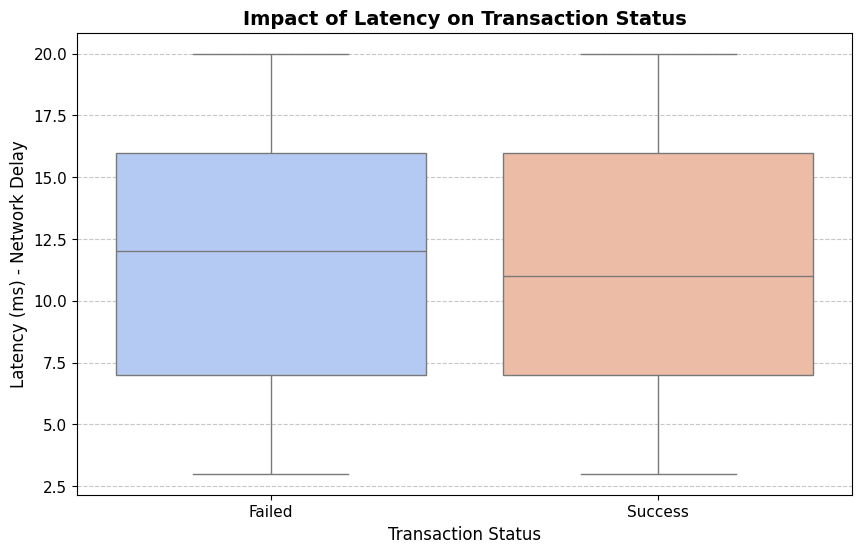

In [21]:
plt.figure(figsize=(10, 6))  # Enlarged for better readability
sns.boxplot(data=df, x='Transaction Status', y='Latency (ms)',hue ='Transaction Status', palette='coolwarm', legend=False)

# Enhancing Labels for Better Understanding
plt.title("Impact of Latency on Transaction Status", fontsize=14, fontweight='bold')
plt.xlabel("Transaction Status", fontsize=12)
plt.ylabel("Latency (ms) - Network Delay", fontsize=12)

# Improving Readability
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Fraud Occurrences by Network Slice
Certain network slices may be more vulnerable to fraud due to varying levels of security.

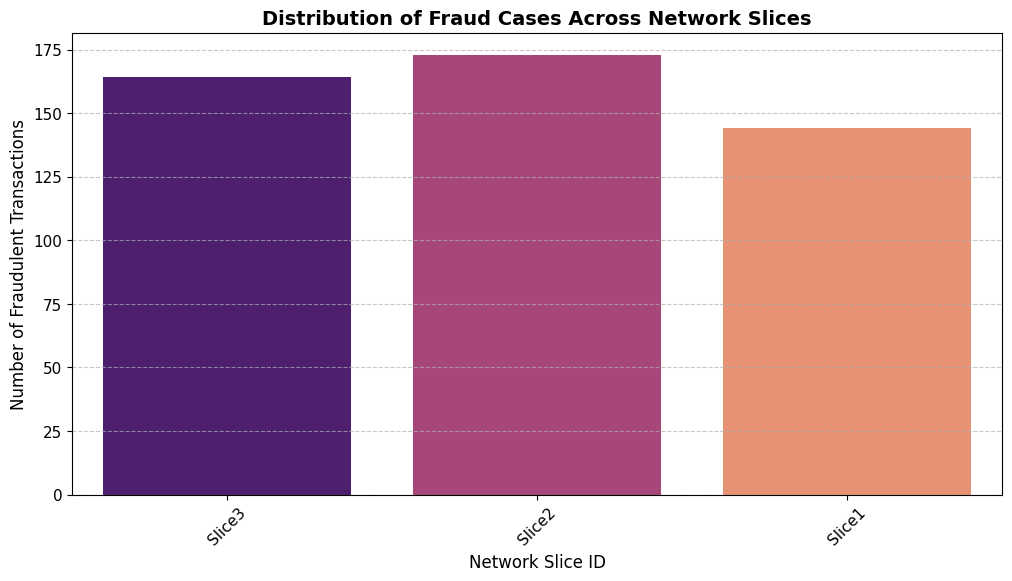

In [22]:
plt.figure(figsize=(12, 6))  # Larger figure for better clarity

# Convert 'Network Slice ID' to a string for proper categorical plotting
df['Network Slice ID'] = df['Network Slice ID'].astype(str)

sns.countplot(data=df[df['Fraud Flag'] == True], x='Network Slice ID',hue='Network Slice ID', palette='magma', legend = False)

# Enhancing Labels for Better Understanding
plt.title("Distribution of Fraud Cases Across Network Slices", fontsize=14, fontweight='bold')
plt.xlabel("Network Slice ID", fontsize=12)
plt.ylabel("Number of Fraudulent Transactions", fontsize=12)

# Rotating X-Ticks for Better Visibility
plt.xticks(rotation=45, fontsize=11)  # Adjust based on slice ID length
plt.yticks(fontsize=11)

# Adding Grid for Better Readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# **5. Recommendations** 

Based on the analysis,the bank should:

**1.** Implement stricter security checks for high-risk transaction types, such as online transfers and withdrawals.

**2.** Enhance fraud detection for mobile transactions, as they show a higher proportion of fraud cases.

**3.** Improve transaction success rates by adrressing failure causes such as network latency and incorrect PIN entries.

**4.** Monitor and flag transactions originating from high-risk geolocations with frequent fraudulent activities.

**5.** Develop machine learning models for fraud prevention based on identified risk factors such as transaction type,network conditions, and device type.




 ## **6. Conclusion**

 This study provide insights into banking transactions,identifying fraud trends and failure patterns.

 **Key Findings**
 
 * Fraud cases are common in certain transaction types (e.g. online transfers, withdrawals).

 * Mobile transactions exhibit a higher risk of fraud.

 * High latency can contribute to failed transactions.

 * Certain network slices are more vulnerable to fraudulent activity.

 * Specific geolocations have  higher fraud occurrences. 

 Future work may involve the development of predictive models using using machine learning techniques to detect fraudulent transactions more accurately and enhance security measures in real-time.


## **7. Next Steps**
Further analyses could provide additional insights to strengthen banking security and improve transaction efficiency:

* Fraud Loss Estimation: Understanding the financial impact of fraudulent transactions on the bank and customers. Analyzing the average loss per fraud case could help justify investments in fraud prevention measures.

* Detailed Failure Analysis: Examining failure reasons in-depth, such as transaction declines due to incorrect PIN entries, insufficient funds, or technical issues. Identifying the most common failure causes would help optimize banking operations.

* Competitor Fraud Prevention Strategies: Analyzing how other financial institutions combat fraud could provide benchmarking opportunities. Studying competitors’ fraud detection techniques and security measures would help enhance fraud prevention strategies.

* Impact of Regulatory Compliance: Investigating how compliance with banking regulations affects fraud detection and prevention. Understanding how adherence to regulatory policies reduces fraud risks would support better security measures.

* Real-time Fraud Detection & Prevention: Implementing machine learning models to detect fraud in real time, allowing proactive prevention. Utilizing AI-driven risk assessment models could enhance transaction security.